# TP MLOps II — Dataset: demanda eléctrica de España

**Dataset:** [`nicholasjhana/energy-consumption-generation-prices-and-weather`](https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather) (Kaggle), basado en datos de [ENTSO-E](https://transparency.entsoe.eu/) (consumo, generación y precio eléctrico) y [Open Weather API](https://openweathermap.org/) (clima).

**Contenido:**
- `energy_dataset.csv`: serie horaria **nacional** de España, 2015-01-01 a 2018-12-31 (35.064 filas = 4 años x 24h). Incluye generación eléctrica por fuente (nuclear, eólica, solar, gas, etc.), forecasts oficiales del operador de red (day-ahead), precio de mercado eléctrico, y la **demanda real** (`total load actual`).
- `weather_features.csv`: clima horario de las **5 ciudades más grandes de España** (Madrid, Barcelona, Valencia, Sevilla, Bilbao) en formato *long* (una fila por ciudad-hora, 178.396 filas).

**Objetivo del TP:** forecasting de la demanda eléctrica horaria (`total load actual`). El dataset trae además el **forecast oficial del operador de red** (`total load forecast`), lo que da un benchmark real de industria para comparar el modelo propio.

Este notebook es el **EDA inicial**: entender la estructura, calidad y principales drivers del dato antes de limpiar y modelar.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

data_path = Path('../data')
raw_data_path = data_path / 'raw'

# Importing the dataset
energy = pd.read_csv(raw_data_path / 'energy_dataset.csv')
weather = pd.read_csv(raw_data_path / 'weather_features.csv')

print(energy.shape)

print(energy.info())
print(weather.shape)
print(weather.info())


(35064, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null 

## 1. Estructura de los datasets

Primer vistazo a ambas tablas: cuántas filas/columnas, tipos de dato, y cómo se ven las primeras filas.

- `energy`: 29 columnas, casi todas numéricas (generación por fuente en MW, forecasts, precios en €/MWh) + `time`.
- `weather`: 17 columnas por ciudad-hora — temperatura (en **Kelvin**), presión, humedad, viento, lluvia/nieve, y una descripción categórica del clima.

In [3]:
energy.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [4]:
weather.head()

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


## 2. Valores faltantes

`weather` no tiene nulos. `energy` sí, y hay dos patrones distintos:
- **Columnas 100% vacías** (`generation hydro pumped storage aggregated`, `forecast wind offshore eday ahead`): no aportan nada, se descartan en la limpieza.
- **Nulos puntuales** (~18-19 filas) en casi todas las columnas de generación, y **36 nulos** en el target `total load actual` — a resolver con interpolación en la limpieza (no en este notebook, que es solo EDA).

In [5]:
print(energy.isnull().sum())

time                                               0
generation biomass                                19
generation fossil brown coal/lignite              18
generation fossil coal-derived gas                18
generation fossil gas                             18
generation fossil hard coal                       18
generation fossil oil                             19
generation fossil oil shale                       18
generation fossil peat                            18
generation geothermal                             18
generation hydro pumped storage aggregated     35064
generation hydro pumped storage consumption       19
generation hydro run-of-river and poundage        19
generation hydro water reservoir                  18
generation marine                                 19
generation nuclear                                17
generation other                                  18
generation other renewable                        18
generation solar                              

In [6]:
print(weather.isnull().sum())

dt_iso                 0
city_name              0
temp                   0
temp_min               0
temp_max               0
pressure               0
humidity               0
wind_speed             0
wind_deg               0
rain_1h                0
rain_3h                0
snow_3h                0
clouds_all             0
weather_id             0
weather_main           0
weather_description    0
weather_icon           0
dtype: int64


### ¿Los nulos están concentrados o esparcidos?

Importante para decidir cómo tratarlos: si fueran un tramo largo continuo, habría que descartar ese período. Si son eventos puntuales, alcanza con interpolar.

El gráfico de abajo cuenta cuántas columnas son nulas en cada fila, a lo largo del tiempo.

<Axes: title={'center': 'Cantidad de nulos por fila a lo largo del tiempo'}, xlabel='time'>

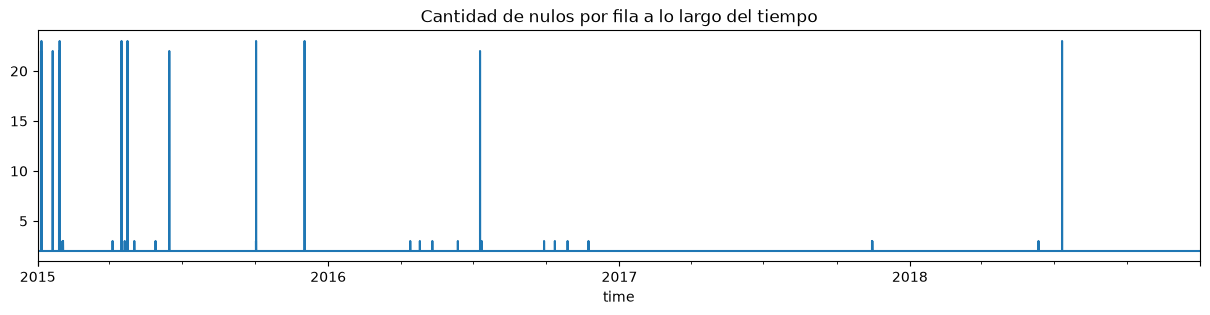

In [7]:
energy_ts = energy.copy()
energy_ts['time'] = pd.to_datetime(energy_ts['time'], utc=True)
energy_ts = energy_ts.set_index('time')

energy_ts.isnull().sum(axis=1).plot(figsize=(15,3), title='Cantidad de nulos por fila a lo largo del tiempo')

**Resultado:** los nulos son picos puntuales y aislados (hasta ~23 columnas nulas en el mismo instante, en momentos específicos), no hay tramos largos faltantes. Confirma que interpolar es seguro, sin perder continuidad en la serie.

## 3. El target: `total load actual`

Distribución general y forma de la serie completa (todavía sin limpiar).

<Axes: >

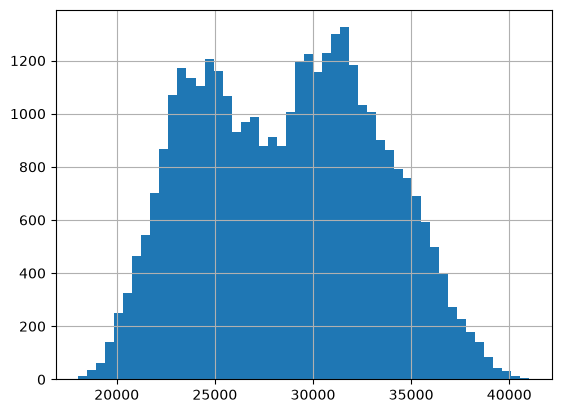

In [11]:
energy['total load actual'].describe()
energy['total load actual'].hist(bins=50)


<Axes: title={'center': 'Demanda eléctrica real (crudo)'}, xlabel='time'>

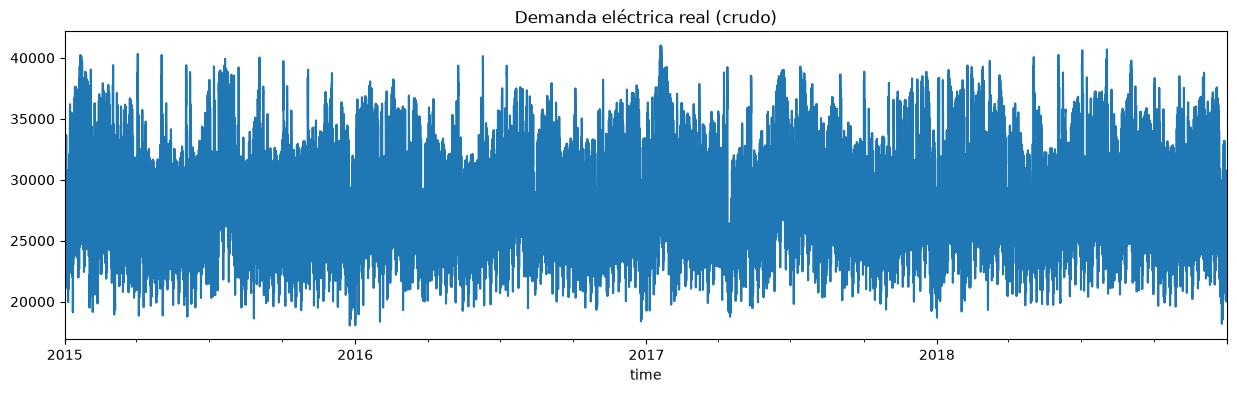

In [9]:
energy_ts['total load actual'].plot(figsize=(15,4), title='Demanda eléctrica real (crudo)')


**Observaciones:**
- La serie no muestra outliers extremos ni huecos visibles a esta escala — es una serie sana.
- El histograma es **bimodal** (dos jorobas, ~23-25k MW y ~29-32k MW), lo que sugiere que hay al menos un factor categórico fuerte separando dos regímenes de consumo. Se investiga a continuación.

## 4. Estacionalidad — las tres escalas temporales

### 4.1. Día de la semana
Hipótesis: el patrón bimodal se debe a fin de semana vs. días hábiles.

<Axes: title={'center': 'total load actual'}, xlabel='dow'>

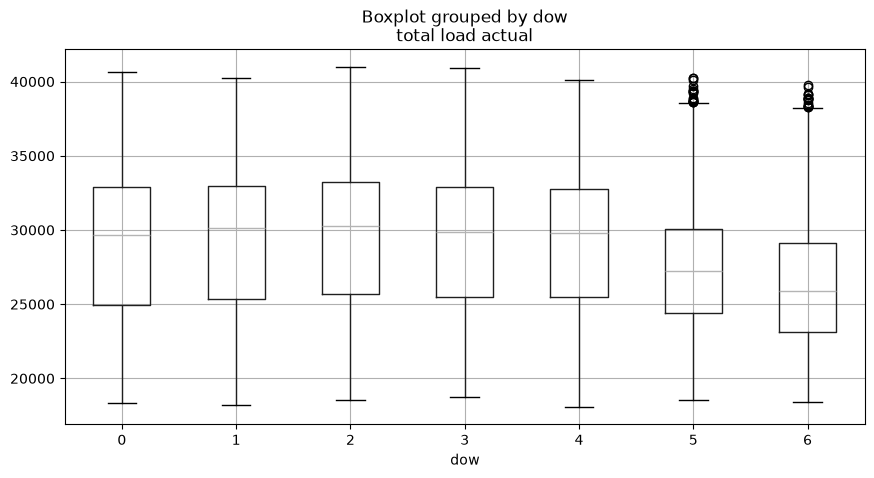

In [12]:
energy_ts['dow'] = energy_ts.index.dayofweek  # 0=lunes, 6=domingo
energy_ts.boxplot(column='total load actual', by='dow', figsize=(10,5))


Hay diferencia (sábado y domingo con mediana más baja), pero los días de semana entre sí son casi idénticos — **no alcanza para explicar un bimodal tan marcado**. Se prueba la hora del día.

### 4.2. Hora del día
Hipótesis: el bimodal es intra-día (valle nocturno vs. meseta diurna).

<Axes: title={'center': 'total load actual'}, xlabel='hour'>

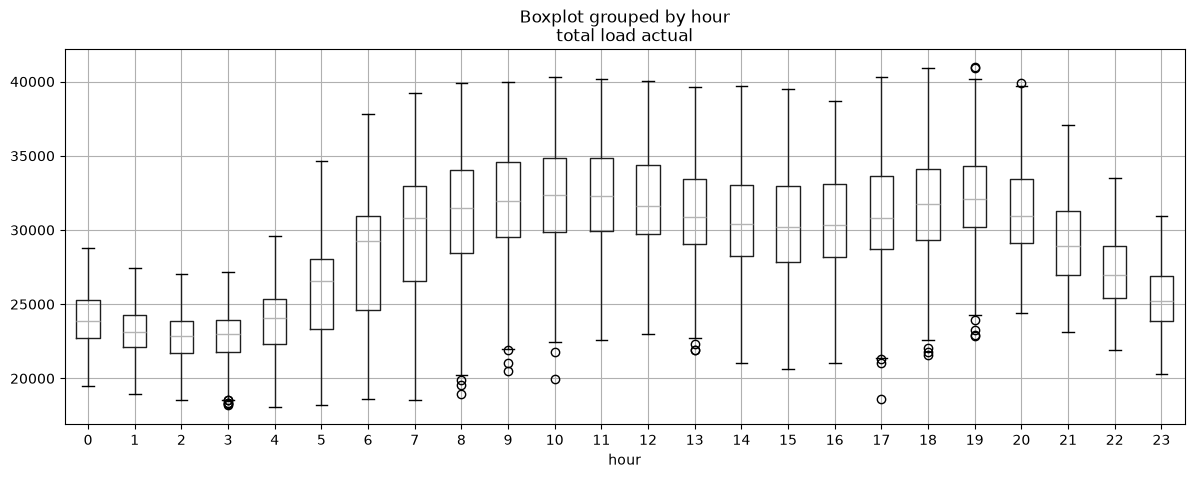

In [13]:
energy_ts['hour'] = energy_ts.index.hour
energy_ts.boxplot(column='total load actual', by='hour', figsize=(14,5))


**Confirmado y es el driver más fuerte del dataset.** Valle marcado entre las 2-4hs (mínimo consumo nocturno) y meseta alta entre las 8-20hs, con transiciones abruptas al amanecer/atardecer. Esto es lo que genera el bimodal del histograma: cada hora "vota" por una de las dos jorobas.

### 4.3. Mes / estacionalidad anual
Efecto de menor magnitud, pero se intuía en la serie completa (picos más altos en ciertos períodos).

<Axes: title={'center': 'total load actual'}, xlabel='month'>

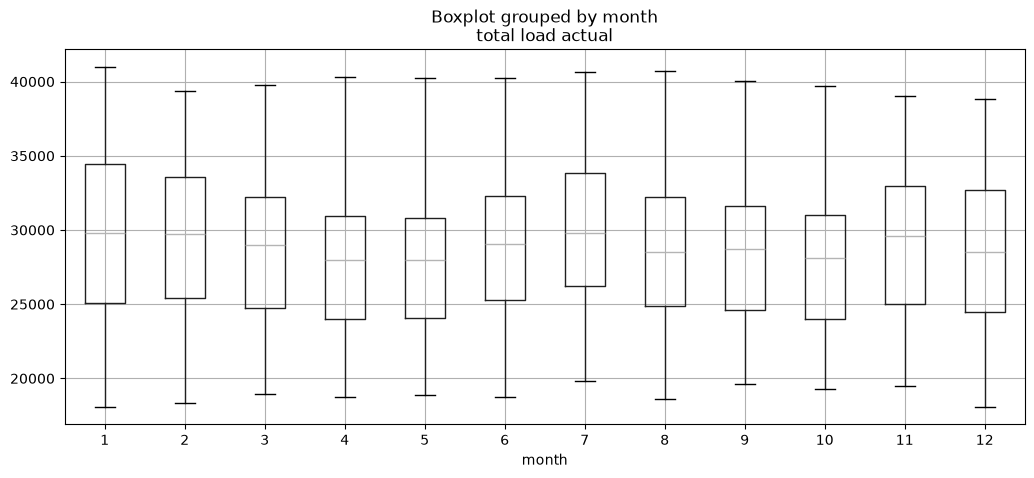

In [14]:
energy_ts['month'] = energy_ts.index.month
energy_ts.boxplot(column='total load actual', by='month', figsize=(12,5))


Forma de **U**: medianas más altas en invierno (dic-feb, calefacción) y en pleno verano (jul, aire acondicionado), con mínimos en las estaciones intermedias (abr-may, sep-oct) donde no se calefacciona ni se refrigera tanto. Efecto real, consistente con el clima de España, aunque más sutil que hora y día de semana.

## 5. Relación con el clima

El patrón mensual en forma de U sugiere que la **temperatura** podría ser la variable subyacente (más que "el mes" en sí). `weather` está en formato *long* (una fila por ciudad-hora); para cruzarlo con `energy` (nacional) se agrega la temperatura promediando las 5 ciudades por hora.

<Axes: xlabel='temp_avg', ylabel='total load actual'>

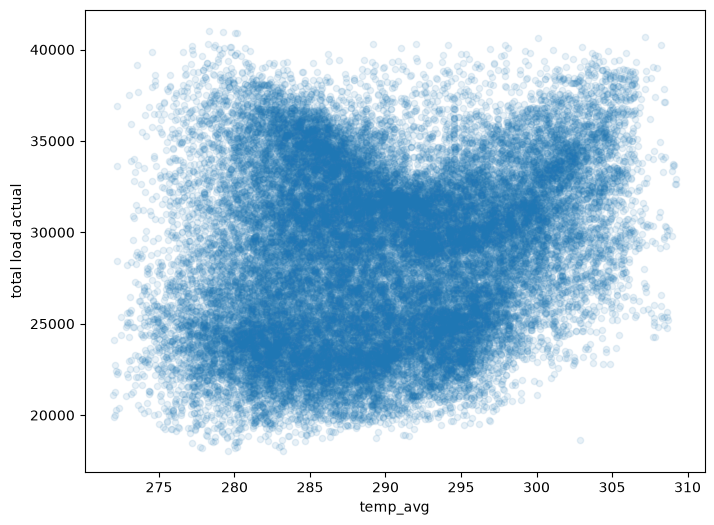

In [15]:
weather['dt_iso'] = pd.to_datetime(weather['dt_iso'], utc=True)
weather_hourly = weather.groupby('dt_iso')['temp'].mean()

merged = energy_ts.join(weather_hourly.rename('temp_avg'), how='left')
merged.plot.scatter(x='temp_avg', y='total load actual', alpha=0.1, figsize=(8,6))


**Resultado clave:** forma de **U casi perfecta**. La demanda es mínima alrededor de los 285-290K (~12-17°C, temperatura de "confort", sin necesidad de climatizar) y sube tanto hacia el frío (~270-275K, calefacción) como hacia el calor extremo (~300-310K, aire acondicionado). Confirma la hipótesis del punto 4.3 y es probablemente el hallazgo más claro del EDA: la temperatura (o la distancia a un punto de confort térmico) es un driver fuerte y no lineal.

### 5.1. ¿Aportan señal distinta las 5 ciudades?

Se usó el promedio nacional de temperatura arriba. Antes de descartar el detalle por ciudad, vale ver qué tan correlacionadas están entre sí — si se mueven todas juntas, el promedio ya captura casi toda la señal; si no, agregar ciudades por separado (o su dispersión) podría sumar información.

In [20]:
weather.groupby('city_name')['temp'].mean().sort_values()

weather_wide = weather.pivot_table(index='dt_iso', columns='city_name', values='temp')
weather_wide.corr()

city_name,Barcelona,Bilbao,Madrid,Seville,Valencia
city_name,,,,,
Barcelona,1.000000,0.866727,0.903996,0.841910,0.917506
Bilbao,0.866727,1.000000,0.872668,0.821292,0.853744
Madrid,0.903996,0.872668,1.000000,0.909421,0.912281
Seville,0.841910,0.821292,0.909421,1.000000,0.860792
Valencia,0.917506,0.853744,0.912281,0.860792,1.000000


Correlaciones altas (0.82-0.92) entre todas las ciudades — el clima ibérico se mueve bastante en sincronía. **Bilbao** es la que más se distingue del resto (correlaciones más bajas, 0.82-0.87), consistente con tener clima atlántico/norte en vez de mediterráneo-continental. No es prioritario, pero queda anotado como posible feature adicional (ej. temperatura de Bilbao aparte, o dispersión entre ciudades).

## 6. Precio de mercado eléctrico vs. demanda

El dataset trae `price actual` (precio real del mercado eléctrico). No es el target, pero es interesante ver su relación con la demanda: en teoría, a mayor demanda, mayor precio (oferta/demanda).

<Axes: xlabel='total load actual', ylabel='price actual'>

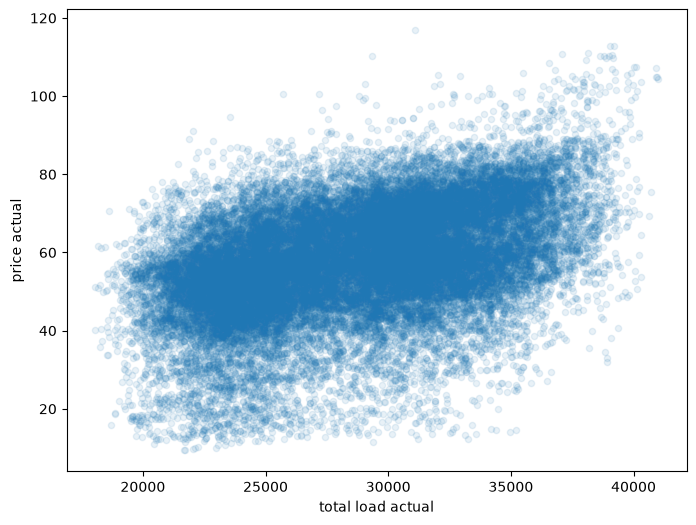

In [19]:
merged['price actual'] = energy_ts['price actual']
merged.plot.scatter(x='total load actual', y='price actual', alpha=0.1, figsize=(8,6))


Correlación positiva pero con bastante dispersión — el precio sube con la demanda en general, pero no es una relación limpia, porque también depende de la mezcla de generación en cada momento (renovables baratas vs. gas caro). No se usaría como feature de entrada para predecir demanda (sería al revés causalmente / posible leakage según el caso de uso), pero es útil como contexto de negocio.

## 7. Conclusiones del EDA

- **Target** (`total load actual`): serie sana, sin outliers extremos, ~36 nulos puntuales a interpolar en la limpieza.
- **Columnas a descartar**: `generation hydro pumped storage aggregated` y `forecast wind offshore eday ahead` (100% nulas).
- **Drivers con señal fuerte**: hora del día (el más fuerte, patrón intra-día muy marcado) y temperatura (relación en U, no lineal).
- **Drivers con señal moderada**: día de la semana (fin de semana más bajo).
- **Drivers con señal débil/redundante**: mes/temporada (se explica en gran parte por temperatura).
- **Extras a considerar**: diferencias de temperatura entre ciudades (Bilbao se distingue del resto), precio de mercado (correlacionado pero ruidoso, más como contexto que como feature predictiva directa).
- **Benchmark disponible**: `total load forecast` es el forecast oficial del operador de red para la misma hora — permite comparar cualquier modelo propio contra el estado del arte de la industria.

**Próximos pasos:** limpieza (dropear columnas vacías, interpolar nulos puntuales), definir split temporal train/test, y armar un baseline de forecasting.